In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from scipy.sparse import load_npz
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from textblob import TextBlob

In [2]:
models_dir = Path("../models/")
dev_data_dir = Path("../data/development/")

with open(models_dir / "nb_bow.pkl", 'rb') as f:
    nb_bow = pickle.load(f)
with open(models_dir / "nb_tfidf.pkl", 'rb') as f:
    nb_tfidf = pickle.load(f)
with open(models_dir / "lr_bow.pkl", 'rb') as f:
    lr_bow = pickle.load(f)
with open(models_dir / "lr_tfidf.pkl", 'rb') as f:
    lr_tfidf = pickle.load(f)
with open(models_dir / "nmf_model.pkl", 'rb') as f:
    nmf_model = pickle.load(f)

In [3]:
X_train_bow = load_npz(dev_data_dir / "X_train_bow.npz")
X_test_bow = load_npz(dev_data_dir / "X_test_bow.npz")
X_train_tfidf = load_npz(dev_data_dir / "X_train_tfidf.npz")
X_test_tfidf = load_npz(dev_data_dir / "X_test_tfidf.npz")

y_train = pd.read_csv(dev_data_dir / "y_train.csv")['sentiment']
y_test = pd.read_csv(dev_data_dir / "y_test.csv")['sentiment']

with open(dev_data_dir / "bow_vectorizer.pkl", 'rb') as f:
    bow_vectorizer = pickle.load(f)
with open(dev_data_dir / "tfidf_vectorizer.pkl", 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

In [4]:
y_pred_nb_bow = nb_bow.predict(X_test_bow)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
y_pred_lr_bow = lr_bow.predict(X_test_bow)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

In [5]:
processed_data_path = Path("../data/processed/processed.csv")
df = pd.read_csv(processed_data_path)

def create_sentiment_labels(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(create_sentiment_labels)

In [6]:
def textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity < -0.1:
        return 'negative'
    elif polarity > 0.1:
        return 'positive'
    else:
        return 'neutral'

test_indices = y_test.index
y_pred_textblob = df.loc[test_indices, 'review'].apply(textblob_sentiment).values

In [7]:
print("Naive Bayes (Bag of Words) Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb_bow):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb_bow, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nb_bow, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_nb_bow, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_bow))

Naive Bayes (Bag of Words) Evaluation:
Accuracy: 0.7991
Precision: 0.7978
Recall: 0.7991
F1 Score: 0.7984

Classification Report:
              precision    recall  f1-score   support

    negative       0.51      0.48      0.49       457
     neutral       0.39      0.40      0.39       588
    positive       0.90      0.91      0.91      3484

    accuracy                           0.80      4529
   macro avg       0.60      0.60      0.60      4529
weighted avg       0.80      0.80      0.80      4529



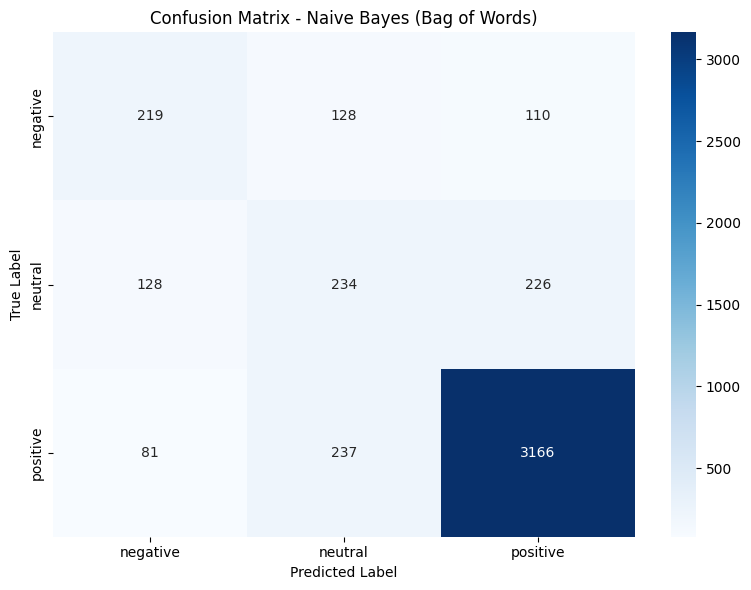

In [8]:
cm_nb_bow = confusion_matrix(y_test, y_pred_nb_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_bow, annot=True, fmt='d', cmap='Blues', xticklabels=nb_bow.classes_, yticklabels=nb_bow.classes_)
plt.title('Confusion Matrix - Naive Bayes (Bag of Words)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/cm_nb_bow.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print("Naive Bayes (TF-IDF) Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb_tfidf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb_tfidf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nb_tfidf, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_nb_tfidf, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_tfidf))

Naive Bayes (TF-IDF) Evaluation:
Accuracy: 0.7823
Precision: 0.7600
Recall: 0.7823
F1 Score: 0.7002

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.11      0.18       457
     neutral       0.64      0.02      0.05       588
    positive       0.78      1.00      0.88      3484

    accuracy                           0.78      4529
   macro avg       0.72      0.38      0.37      4529
weighted avg       0.76      0.78      0.70      4529



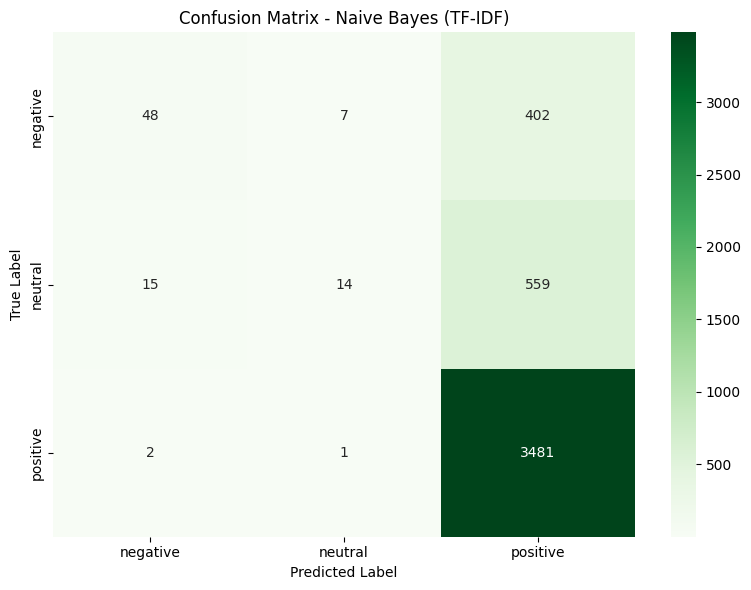

In [10]:
cm_nb_tfidf = confusion_matrix(y_test, y_pred_nb_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_tfidf, annot=True, fmt='d', cmap='Greens', xticklabels=nb_tfidf.classes_, yticklabels=nb_tfidf.classes_)
plt.title('Confusion Matrix - Naive Bayes (TF-IDF)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/cm_nb_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print("Logistic Regression (Bag of Words) Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_bow):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_bow, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_bow, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr_bow, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_bow))

Logistic Regression (Bag of Words) Evaluation:
Accuracy: 0.8117
Precision: 0.7798
Recall: 0.8117
F1 Score: 0.7894

Classification Report:
              precision    recall  f1-score   support

    negative       0.51      0.45      0.48       457
     neutral       0.44      0.23      0.30       588
    positive       0.87      0.96      0.91      3484

    accuracy                           0.81      4529
   macro avg       0.61      0.54      0.56      4529
weighted avg       0.78      0.81      0.79      4529



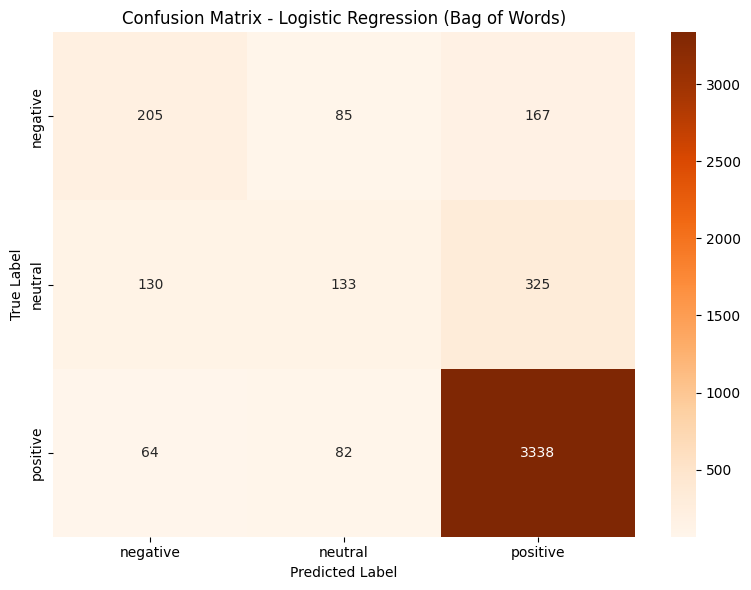

In [12]:
cm_lr_bow = confusion_matrix(y_test, y_pred_lr_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_bow, annot=True, fmt='d', cmap='Oranges', xticklabels=lr_bow.classes_, yticklabels=lr_bow.classes_)
plt.title('Confusion Matrix - Logistic Regression (Bag of Words)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/cm_lr_bow.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print("Logistic Regression (TF-IDF) Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_tfidf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tfidf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_tfidf, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr_tfidf, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tfidf))

Logistic Regression (TF-IDF) Evaluation:
Accuracy: 0.8136
Precision: 0.7780
Recall: 0.8136
F1 Score: 0.7864

Classification Report:
              precision    recall  f1-score   support

    negative       0.54      0.40      0.46       457
     neutral       0.47      0.22      0.30       588
    positive       0.86      0.97      0.91      3484

    accuracy                           0.81      4529
   macro avg       0.62      0.53      0.56      4529
weighted avg       0.78      0.81      0.79      4529



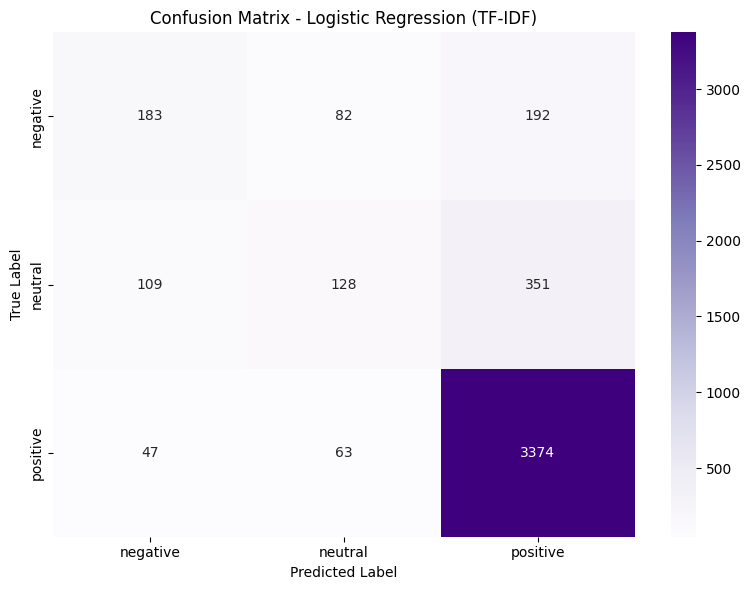

In [14]:
cm_lr_tfidf = confusion_matrix(y_test, y_pred_lr_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_tfidf, annot=True, fmt='d', cmap='Purples', xticklabels=lr_tfidf.classes_, yticklabels=lr_tfidf.classes_)
plt.title('Confusion Matrix - Logistic Regression (TF-IDF)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/cm_lr_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
print("TextBlob (Rule-Based) Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_textblob):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_textblob, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_textblob, average='weighted', zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_textblob, average='weighted', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_textblob, zero_division=0))

TextBlob (Rule-Based) Evaluation:
Accuracy: 0.6500
Precision: 0.6188
Recall: 0.6500
F1 Score: 0.6306

Classification Report:
              precision    recall  f1-score   support

    negative       0.10      0.02      0.03       457
     neutral       0.13      0.17      0.15       588
    positive       0.77      0.81      0.79      3484

    accuracy                           0.65      4529
   macro avg       0.33      0.33      0.32      4529
weighted avg       0.62      0.65      0.63      4529



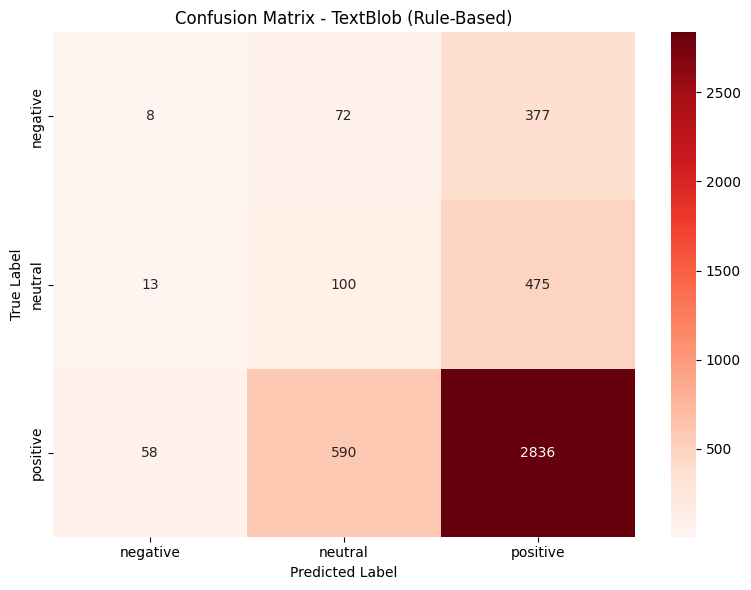

In [16]:
labels_textblob = sorted(list(set(y_test) | set(y_pred_textblob)))
cm_textblob = confusion_matrix(y_test, y_pred_textblob, labels=labels_textblob)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_textblob, annot=True, fmt='d', cmap='Reds', xticklabels=labels_textblob, yticklabels=labels_textblob)
plt.title('Confusion Matrix - TextBlob (Rule-Based)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/cm_textblob.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
models_summary = {
    'Model': [
        'Naive Bayes (BoW)', 
        'Naive Bayes (TF-IDF)', 
        'Logistic Regression (BoW)', 
        'Logistic Regression (TF-IDF)',
        'TextBlob (Rule-Based)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb_bow),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_lr_bow),
        accuracy_score(y_test, y_pred_lr_tfidf),
        accuracy_score(y_test, y_pred_textblob)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb_bow, average='weighted'),
        precision_score(y_test, y_pred_nb_tfidf, average='weighted'),
        precision_score(y_test, y_pred_lr_bow, average='weighted'),
        precision_score(y_test, y_pred_lr_tfidf, average='weighted'),
        precision_score(y_test, y_pred_textblob, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb_bow, average='weighted'),
        recall_score(y_test, y_pred_nb_tfidf, average='weighted'),
        recall_score(y_test, y_pred_lr_bow, average='weighted'),
        recall_score(y_test, y_pred_lr_tfidf, average='weighted'),
        recall_score(y_test, y_pred_textblob, average='weighted', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb_bow, average='weighted'),
        f1_score(y_test, y_pred_nb_tfidf, average='weighted'),
        f1_score(y_test, y_pred_lr_bow, average='weighted'),
        f1_score(y_test, y_pred_lr_tfidf, average='weighted'),
        f1_score(y_test, y_pred_textblob, average='weighted', zero_division=0)
    ]
}

summary_df = pd.DataFrame(models_summary)
summary_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes (BoW),0.799073,0.797807,0.799073,0.798377
1,Naive Bayes (TF-IDF),0.782292,0.759973,0.782292,0.700220
2,Logistic Regression (BoW),0.811658,0.779847,0.811658,0.789383
3,Logistic Regression (TF-IDF),0.813645,0.777968,0.813645,0.786390
4,TextBlob (Rule-Based),0.650033,0.618806,0.650033,0.630622


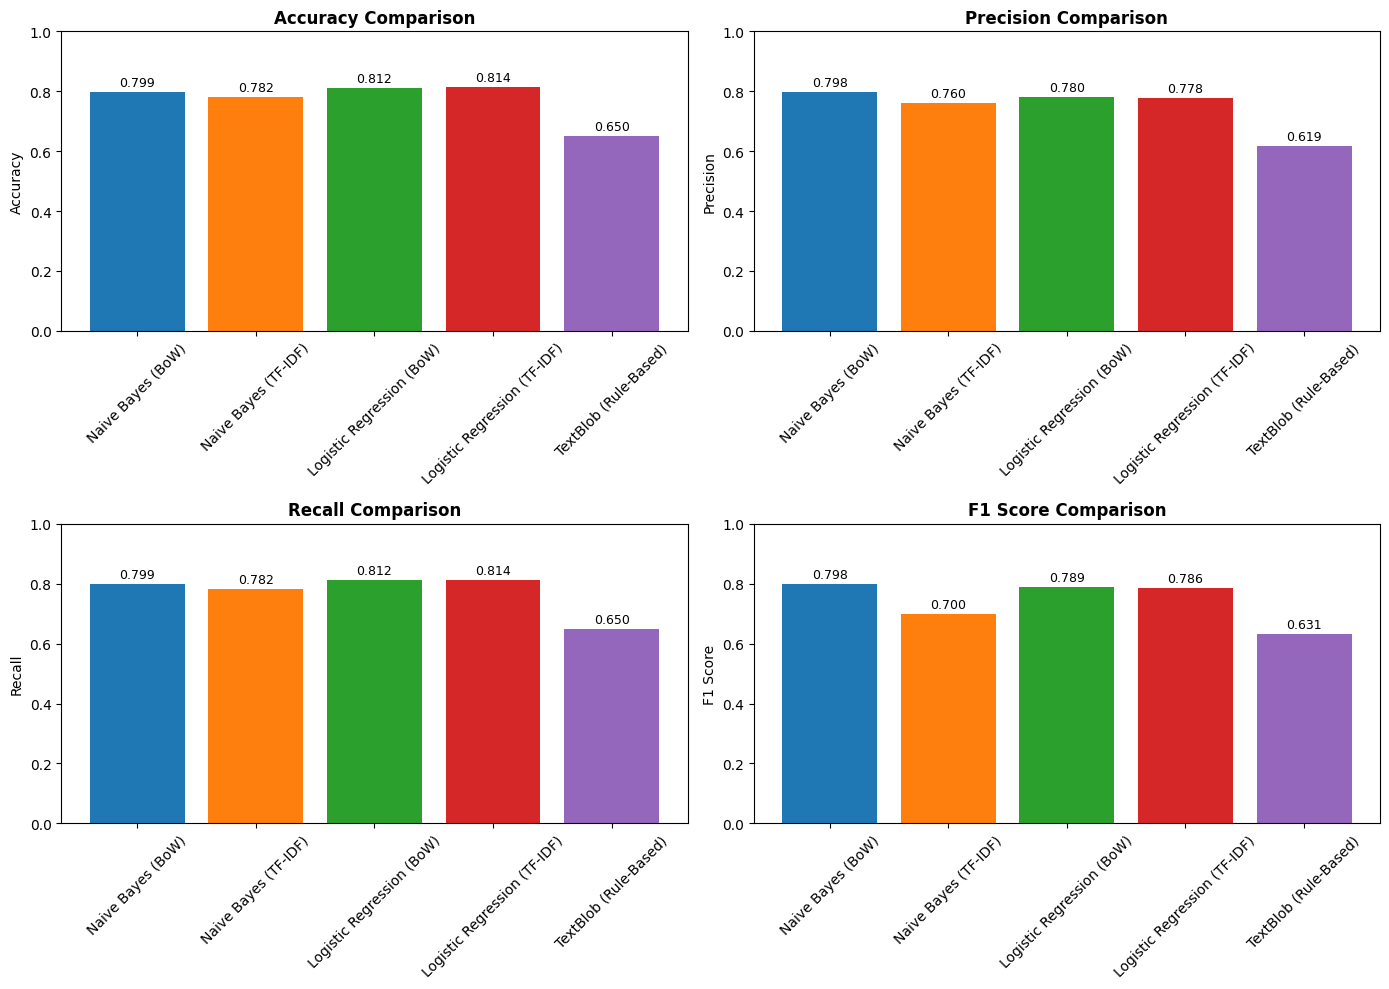

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(summary_df['Model'], summary_df[metric], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(summary_df[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
summary_df.to_csv('../reports/model_evaluation_summary.csv', index=False)